In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os.path as op
from typing import Tuple, Iterator
# EEG utilities
import mne
# BIDS utilities
from util.io.bids import DataSink
from bids import BIDSLayout
# PLV functions
from util.io.ffr import read_epochs
# from util.io.plv import *
from scipy.stats import shapiro, mannwhitneyu

### Compute PLVs

In [2]:
def read_epochs(BIDS_ROOT, sub, desc):
    '''
    reads and concatenates epochs across runs
    '''
    from bids import BIDSLayout
    layout = BIDSLayout(BIDS_ROOT, derivatives = True)
    run = lambda f: int(re.findall('run-(\w+)_', f)[0])
    fnames = layout.get(
        return_type = 'filename',
        subject = sub, 
        desc = desc
        )
    print(fnames)
    fnames.sort(key = run)
    epochs_all = [mne.read_epochs(f) for f in fnames]
    epochs = mne.concatenate_epochs(epochs_all)
    epochs = epochs.pick('eeg')
    return epochs

condition_mapping = {
    '11': [130, 130], # [target freq, stim freq]
    '12': [130, 200],
    '13': [130, 280],
    '21': [200, 130],
    '22': [200, 200],
    '23': [200, 280],
    '31': [280, 130],
    '32': [280, 200],
    '33': [280, 280],
}

def add_metadata(epochs, condition_mapping):
    mapping = {epochs.event_id[key]: key for key in epochs.event_id}
    tags = np.array([mapping[ev] for ev in epochs.events[:, -1]])
    target = np.array([condition_mapping[tag][0] for tag in tags])
    stim = np.array([condition_mapping[tag][1] for tag in tags])
    df = pd.DataFrame({'target': target, 'stim': stim})
    epochs.metadata = df
    return epochs

In [4]:
# np.random.seed(42)

# BIDS_ROOT = '../data/bids'
# DERIV_ROOT = '../data/bids/derivatives'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True)
# subs = layout.get_subjects(scope = 'preprocess_ffr')
# subs.sort(key = int)

# stim_freqs = [130, 200, 280]

# # Bootstrapping params
# draws = 1000
# n_obs = 400 # determined using find-n-epochs-per-conditions.ipynb

# # Load the data from one subject
# for sub in subs:

#     # read FFR epochs
#     epochs = read_epochs(BIDS_ROOT, sub, 'forFFR')

#     # Crop
#     epochs = epochs.crop(tmin = 0)

#     # Add condition labels
#     epochs = add_metadata(epochs, condition_mapping)
    
#     sub_plvs = pd.DataFrame()
#     for stim_freq in stim_freqs:
#         plvs = np.array([])
#         for i in range(draws):
            
#             # Select data by condition
#             data_array = epochs[f"stim == {stim_freq}"].get_data(copy = True)
#             data_array = np.squeeze(data_array)
            
#             # Draw n random observations
#             draw = data_array[np.random.randint(1, np.shape(data_array)[0], n_obs), :]
        
#             # Constants for computing FFT
#             N = np.shape(draw)[1] # time points
#             fs = 5000 # sampling rate
#             T = 1/fs # msec of each time point
        
#             # Compute FFTs of each signal
#             ffts = np.fft.fft(draw)
                
#             # # Extract the frequency bin of interest (e.g., approximating 10 Hz)
#             freqs = np.fft.fftfreq(N, d = T) 
#             idx = np.abs(freqs - stim_freq).argmin()
        
#             # Extract the phase information
#             phases = np.angle(ffts[:, idx])
            
#             # Compute the PLV as the average value for the draw
#             plv = np.abs(np.mean(np.exp(1j * phases)))
#             plvs = np.append(plvs, plv)
        
#             # Plot
#             # plot_polar_vectors(phases)
#             # break
    
#         # Create dataframe
#         condition_plvs = pd.DataFrame({
#             'sub': sub,
#             'stim_freq': stim_freq,
#             'draw': list(range(1, draws+1)),
#             'plv': plvs
#         })
#         sub_plvs = pd.concat([sub_plvs, condition_plvs], ignore_index = True)

#     sink = DataSink(DERIV_ROOT, 'plv')
#     path = sink.make_dir(sub)
#     fname = op.join(path, 'plv.csv')
#     sub_plvs.to_csv(fname, index = False)
#     # break

### Compute null

<Axes: ylabel='Count'>

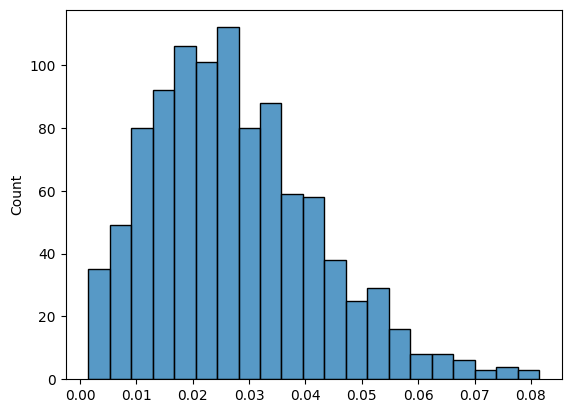

In [3]:
np.random.seed(42)
draws = 1000
null = np.array([])

for i in range(draws):
    # Draw random phases from a uniform distribution
    phases = np.random.uniform(low = 0, high = 2*np.pi, size = 1000)
    plv = np.abs(np.mean(np.exp(1j * phases)))
    null = np.append(null, plv)

sns.histplot(null)

### PLVs to each tone

In [4]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')

plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

plvs

,sub,stim_freq,draw,plv
0,7,130,1,0.030975
1,7,130,2,0.033188
2,7,130,3,0.013108
3,7,130,4,0.057135
4,7,130,5,0.074935
...,...,...,...,...
125995,35,280,996,0.059334
125996,35,280,997,0.113223
125997,35,280,998,0.013293
125998,35,280,999,0.049950


<Axes: xlabel='plv', ylabel='Count'>

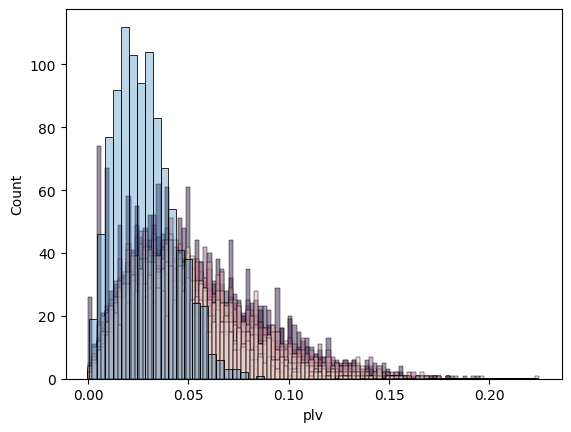

In [6]:
# 130 Hz 
plvs_130 = plvs[plvs.stim_freq == 130]
sns.histplot(plvs_130, x = "plv", hue = "sub", legend = False)
sns.histplot(null, alpha = 0.3)

<Axes: xlabel='plv', ylabel='Count'>

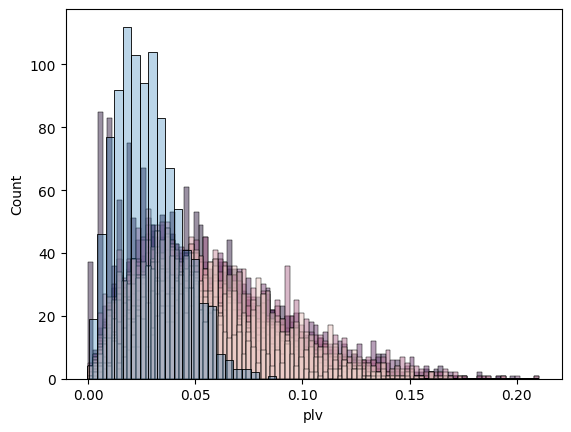

In [7]:
# 200 Hz 
plvs_200 = plvs[plvs.stim_freq == 200]
sns.histplot(plvs_200, x = "plv", hue = "sub", legend = False)
sns.histplot(null, alpha = 0.3)

<Axes: xlabel='plv', ylabel='Count'>

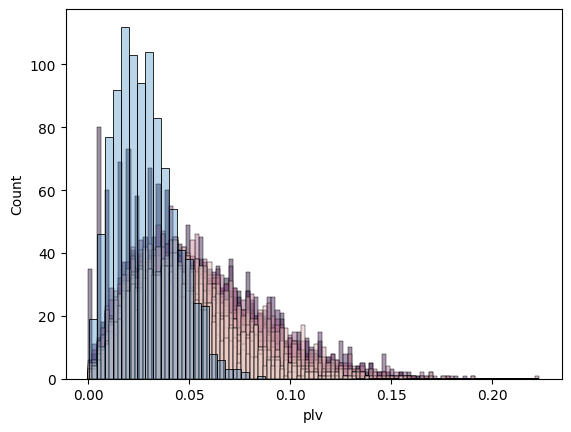

In [8]:
# 280 Hz
plvs_280 = plvs[plvs.stim_freq == 280]
sns.histplot(plvs_280, x = "plv", hue = "sub", legend = False)
sns.histplot(null, alpha = 0.3)

### Tests

In [9]:
print(shapiro(plvs_130.plv))
print(shapiro(plvs_200.plv))
print(shapiro(plvs_280.plv))

ShapiroResult(statistic=0.9538701772689819, pvalue=0.0)
ShapiroResult(statistic=0.9591856598854065, pvalue=0.0)
ShapiroResult(statistic=0.9683161377906799, pvalue=0.0)


/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [10]:
print(mannwhitneyu(plvs_130.plv, null))
print(mannwhitneyu(plvs_200.plv, null))
print(mannwhitneyu(plvs_280.plv, null))

MannwhitneyuResult(statistic=30928755.0, pvalue=1.824636930835099e-144)
MannwhitneyuResult(statistic=31879182.0, pvalue=4.875916443420469e-173)
MannwhitneyuResult(statistic=31900785.0, pvalue=1.019386400194887e-173)


# PLVs by accuracy

In [5]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')
plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [6]:
# Add accuracy group to dataframe
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
accuracy = accuracy.rename(columns = {'subject': 'subj'})
plvs = plvs.rename(columns = {'sub': 'subj'})
plvs = plvs.merge(accuracy, left_on = ["subj"], right_on = ["subj"])
plvs

,subj,stim_freq,draw,plv,accuracy,score_group
0,7,130,1,0.030975,0.915718,low
1,7,130,2,0.033188,0.915718,low
2,7,130,3,0.013108,0.915718,low
3,7,130,4,0.057135,0.915718,low
4,7,130,5,0.074935,0.915718,low
...,...,...,...,...,...,...
125995,35,280,996,0.059334,0.980110,high
125996,35,280,997,0.113223,0.980110,high
125997,35,280,998,0.013293,0.980110,high
125998,35,280,999,0.049950,0.980110,high


In [7]:
# Readjust median split
med = np.median(plvs.accuracy)
print(med)
plvs.loc[plvs['accuracy'] > med, 'accuracy_group'] = 'high'
plvs.loc[plvs['accuracy'] < med, 'accuracy_group'] = 'low'

0.9318634007604594


In [3]:
# Create null
np.random.seed(42)
draws = 1000 #20000
null = np.array([])

for i in range(draws):
    # Draw random phases from a uniform distribution
    phases = np.random.uniform(low = 0, high = 2*np.pi, size = 1000)
    plv = np.abs(np.mean(np.exp(1j * phases)))
    null = np.append(null, plv)
# sns.histplot(null, color = 'white')

# Get 95% CI
CI90 = np.percentile(null, 90)
print(f'90% CI: {CI90}')
CI95 = np.percentile(null, 95)
print(f'95% CI: {CI95}')

# Create null dataframe
null = pd.DataFrame({
    'subj': 'null',
    'accuracy_group': 'null',
    'plv': null,
    'stim_freq': 'null'
})

90% CI: 0.04721499210741834
95% CI: 0.05433753687519568


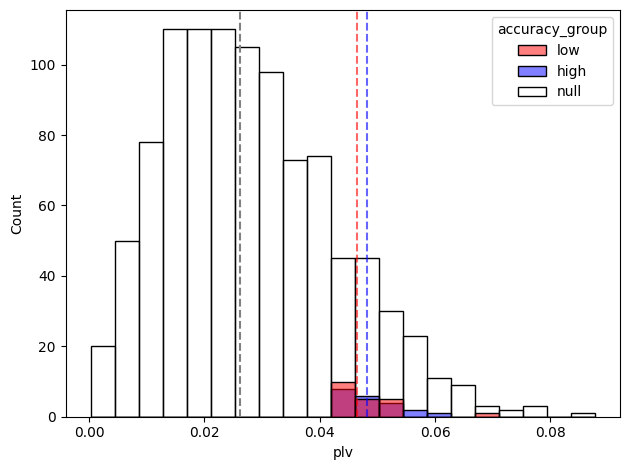

In [23]:
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])
sns.histplot(plvs_130, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
plt.savefig("../figs/PLV-130-hz.png", dpi = 300)

In [16]:
descriptives = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

,accuracy_group,med,Q1,Q3,IQR
0,high,0.048239,0.045606,0.050755,0.005149
1,low,0.046442,0.044678,0.051168,0.006490
2,null,0.026198,0.016660,0.037458,0.020798


**Tests**

In [17]:
high = plvs_130[plvs_130.accuracy_group == 'high']
low = plvs_130[plvs_130.accuracy_group == 'low']
null = plvs_130[plvs_130.accuracy_group == 'null']

print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))
print(mannwhitneyu(high.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(low.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(high.plv, low.plv))

ShapiroResult(statistic=0.8646854162216187, pvalue=0.0076875402592122555)
ShapiroResult(statistic=0.7548198103904724, pvalue=0.00014443541294895113)
ShapiroResult(statistic=0.9714277982711792, pvalue=4.017865142154353e-13)
MannwhitneyuResult(statistic=18925.0, pvalue=1.49393340316778e-10)
MannwhitneyuResult(statistic=18679.0, pvalue=4.813917801290989e-10)
MannwhitneyuResult(statistic=273.0, pvalue=0.1908399057704352)


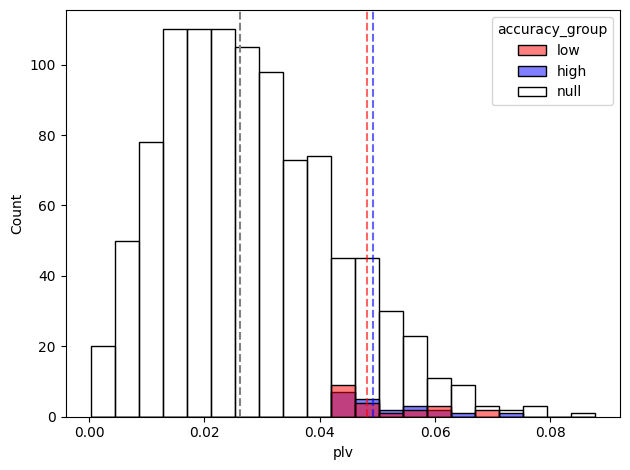

In [24]:
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])
sns.histplot(plvs_200, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
plt.savefig("../figs/PLV-200-hz.png", dpi = 300)

In [19]:
descriptives = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

,accuracy_group,med,Q1,Q3,IQR
0,high,0.049263,0.044558,0.057169,0.012611
1,low,0.048225,0.045279,0.056840,0.011560
2,null,0.026198,0.016660,0.037458,0.020798


**Tests**

In [20]:
high = plvs_200[plvs_200.accuracy_group == 'high']
low = plvs_200[plvs_200.accuracy_group == 'low']
null = plvs_200[plvs_200.accuracy_group == 'null']

print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))
print(mannwhitneyu(high.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(low.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(high.plv, low.plv))

ShapiroResult(statistic=0.8890308141708374, pvalue=0.021566271781921387)
ShapiroResult(statistic=0.8595070242881775, pvalue=0.0062211547046899796)
ShapiroResult(statistic=0.9714277982711792, pvalue=4.017865142154353e-13)
MannwhitneyuResult(statistic=19158.0, pvalue=4.783728258543872e-11)
MannwhitneyuResult(statistic=19076.0, pvalue=7.166224548225691e-11)
MannwhitneyuResult(statistic=226.0, pvalue=0.89990710207531)


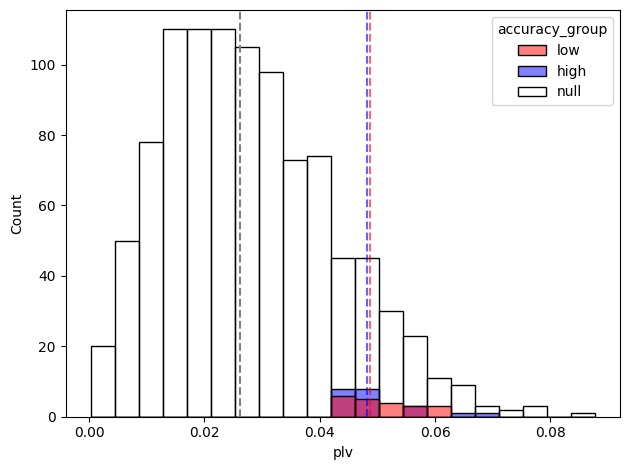

In [25]:
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])
sns.histplot(plvs_280, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
plt.savefig("../figs/PLV-280-hz.png", dpi = 300)

In [22]:
descriptives = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

,accuracy_group,med,Q1,Q3,IQR
0,high,0.048167,0.045417,0.049966,0.004548
1,low,0.048761,0.045595,0.054513,0.008918
2,null,0.026198,0.016660,0.037458,0.020798


**Tests**

In [23]:
high = plvs_280[plvs_280.accuracy_group == 'high']
low = plvs_280[plvs_280.accuracy_group == 'low']
null = plvs_280[plvs_280.accuracy_group == 'null']

print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))
print(mannwhitneyu(high.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(low.plv, null.plv, alternative = 'greater'))
print(mannwhitneyu(high.plv, low.plv))

ShapiroResult(statistic=0.7698201537132263, pvalue=0.00023486574355047196)
ShapiroResult(statistic=0.9060486555099487, pvalue=0.04591077193617821)
ShapiroResult(statistic=0.9714277982711792, pvalue=4.017865142154353e-13)
MannwhitneyuResult(statistic=18924.0, pvalue=1.5011567332395014e-10)
MannwhitneyuResult(statistic=19115.0, pvalue=5.91573656821608e-11)
MannwhitneyuResult(statistic=201.0, pvalue=0.632679341784771)


<Axes: xlabel='stim_freq', ylabel='plv'>

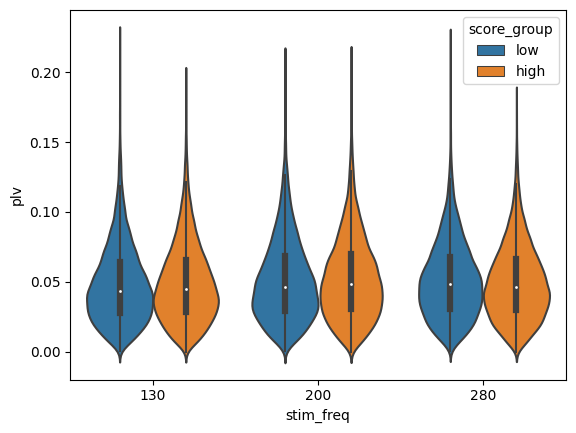

In [21]:
plvs
sns.violinplot(plvs, x = 'stim_freq', hue = 'score_group', y = 'plv')

In [35]:
plvs_all

,subj,accuracy_group,plv,stim_freq,draw,accuracy,score_group
0,null,null,0.030293,null,NaN,NaN,NaN
1,null,null,0.056302,null,NaN,NaN,NaN
2,null,null,0.025570,null,NaN,NaN,NaN
3,null,null,0.020017,null,NaN,NaN,NaN
4,null,null,0.015836,null,NaN,NaN,NaN
...,...,...,...,...,...,...,...
125995,35,high,0.059334,280,996.0,0.98011,high
125996,35,high,0.113223,280,997.0,0.98011,high
125997,35,high,0.013293,280,998.0,0.98011,high
125998,35,high,0.049950,280,999.0,0.98011,high


In [36]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

plvs_all = pd.concat([null, plvs])

# Model specification
model = ols('plv ~ C(accuracy_group) + C(stim_freq) + C(stim_freq) * C(accuracy_group)', data=plvs_all).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/statsmodels/base/model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/statsmodels/base/model.py:1917: RuntimeWarning: invalid value encountered in divide
  F /= J
/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/statsmodels/base/model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/statsmodels/base/model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 3
  warnings.warn('covariance of constraints does not have full '


<Axes: xlabel='stim_freq', ylabel='plv'>

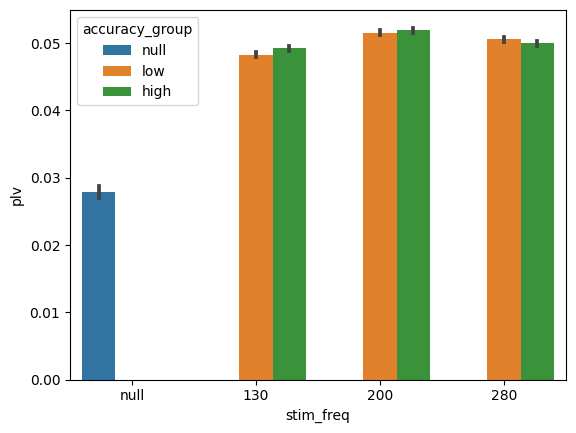

In [34]:
sns.barplot(plvs_all, x = 'stim_freq', hue = 'accuracy_group', y = 'plv')

In [29]:
plvs_all

,subj,accuracy_group,plv,stim_freq,draw,accuracy,score_group
0,null,null,0.030293,NaN,NaN,NaN,NaN
1,null,null,0.056302,NaN,NaN,NaN,NaN
2,null,null,0.025570,NaN,NaN,NaN,NaN
3,null,null,0.020017,NaN,NaN,NaN,NaN
4,null,null,0.015836,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
125995,35,high,0.059334,280.0,996.0,0.98011,high
125996,35,high,0.113223,280.0,997.0,0.98011,high
125997,35,high,0.013293,280.0,998.0,0.98011,high
125998,35,high,0.049950,280.0,999.0,0.98011,high


# PLVs by predictability